# Optimization Benchmark given different Perturbation to the Original Field
Ported from MATLAB: spectral_main.m + 6 helper .m files.

All operations are 2D spectral (surface only).
Uses JAX for JIT compilation, GPU acceleration, and auto-differentiation.

In [185]:
# Packages

import jax
# Enable 64-bit
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
from jax import jit
import jaxopt
import matplotlib
# matplotlib.use('Agg')          # headless, no Tk
import matplotlib.pyplot as plt
import numpy as np
import os
import time
import tkinter as tk
from tkinter import filedialog
import scipy.io as sio
import sys
import dill

# For fourier transform
from numpy.fft import rfft2, irfft2

# Input subfiles
%reload_ext autoreload
%autoreload 2

sys.path.insert(0, os.path.join(os.path.dirname(os.path.abspath("__file__")), '..'))
from physics_functions import calculate_surface_u, forward_ssh
from cost_functions import cost_function_fmin
from ssh_setup import ssh_setup
from perturbation_setup import build_all_perturbations, print_rms_table

# from plotting import plot_surface_fields



In [186]:
# # Reload data

# with open('workspace_0412_afternoon.pkl', 'rb') as f:
#     ws = dill.load(f)
# globals().update(ws)

# %matplotlib inline
# import matplotlib.pyplot as plt


# Load the Data

In [187]:
import sys

print("Select an SSH data file (.mat)... Press Cancel to use default SSH_setup")
root = tk.Tk()
root.withdraw()

file_path = filedialog.askopenfilename(
    title="Select an SSH data file (.mat)",
    filetypes=[("MATLAB Data Files", "*.mat"), ("All Files", "*.*")]
)

mat_contents = sio.loadmat(file_path)
# Find the relevant array (expecting buoyancy 'bout')
key = 'bout'
b_s_data = mat_contents[key]
b_s = b_s_data[:, :, -1]
print(f"Loaded 3D buoyancy data from {file_path}, using the last period.")

# Normalization
b_s_normalized = b_s / jnp.max(jnp.abs(b_s))

Nx, Ny = b_s_normalized.shape
print(f"Grid size adjusted automatically to Nx={Nx}, Ny={Ny}.")
data_name = os.path.splitext(os.path.basename(file_path))[0]


Select an SSH data file (.mat)... Press Cancel to use default SSH_setup
Loaded 3D buoyancy data from D:/Documents/College/Research/Oceangrophy/Shafer_Project/SQG_Simulations/Shafer Simulation output/20260327_231933_Shafer_Simulation_random_IC/20260327_231933_Shafer_Simulation_random_IC.mat, using the last period.
Grid size adjusted automatically to Nx=128, Ny=128.


# Non-Dimensionalization

In Shafer Simulation, everything is already non-dimensional.

I see $ L = 2 \pi$ grid size varies from $n = 64$ to $n = 128$ and $n = 256$. The peak wavenumber is $K_0 = 9.5$. 

## Set Up Parameters

Variables are non-dimentionalized here. Still not sure how's everything done. 

In [ ]:
# Rossby Number 

Ro = 0.01

In [ ]:
# Universal for channel model 

Lx = 2.0 * jnp.pi
Ly = 2.0 * jnp.pi
# Non-Dimensional Parameters
Bu = 1.0

epsilon = Ro
scale = 0.001

# ── Grid Setup (initialize.m) ──
dx = Lx / Nx
dy = Ly / Ny
x = jnp.arange(Nx) * dx
y = jnp.arange(Ny) * dy
X, Y = jnp.meshgrid(x, y, indexing='ij')

# Spectral grid
dk = 2.0 * jnp.pi / Nx
dl = 2.0 * jnp.pi / Ny
k_zonal     = jnp.concatenate([jnp.arange(Nx//2), jnp.arange(-Nx//2, 0)]) * dk
l_meridional = jnp.concatenate([jnp.arange(Ny//2), jnp.arange(-Ny//2, 0)]) * dl
k_zonal      = k_zonal.at[Nx//2].set(0.0)      # kill Nyquist
l_meridional = l_meridional.at[Ny//2].set(0.0)
kx, ky = jnp.meshgrid(k_zonal, l_meridional, indexing='ij')

print(kx)


# The square of K
K2 = kx**2 + ky**2
K = jnp.sqrt(K2)

# Safe inverses (avoid division by zero at k=0)
inv_K = jnp.where(K > 0, 1.0 / K, 0.0)
inv_K2 = jnp.where(K2 > 0, 1.0 / K2, 0.0)

# This is for taking derivative in $z$ direction.
mu = jnp.sqrt(Bu) * K
inv_mu = jnp.where(mu > 0, 1.0 / mu, 0.0)

# True Sea Surface Height

From the Simulation, we have surface buoyancy $b^s$. Under non-dimensionalized setting, 

$$ b^s = \frac{\partial \psi}{\partial z} \Big|_{z = 0} $$

Then undere QG setting, 

$$ \eta^s = \psi^s $$


In [ ]:
# Surface Streamfunction
b_s_hat = jnp.fft.fft2(b_s_normalized)
phi0_s_hat = b_s_hat * inv_mu
phi0_s = jnp.real(jnp.fft.ifft2(phi0_s_hat))

# Surface Sea height, true data
ssh_qg = phi0_s
ssh_qg_hat = phi0_s_hat

# import
from physics_functions import cyclogeo_term, vorticity_term, forward_ssh

eta_tar_hat = forward_ssh(ssh_qg_hat, kx, ky, mu, inv_mu, K2, inv_K2, Bu, epsilon)

# Revert to Physical Space
eta_tar = jnp.real(jnp.fft.ifft2(eta_tar_hat))

# Build the Perturbed Surface Sea Height

In [190]:
rng_key = jax.random.PRNGKey(42)

cases = build_all_perturbations(
    ssh_qg, ssh_qg_hat, kx, ky, K, K2, inv_K2,
    mu, inv_mu, Bu, Ro, X, Y, Lx, Ly, rng_key
, perturb_streamfunction=False)

# Validate the scale
# print_rms_table(cases, ssh_qg, Ro)

In [191]:
# Display the magnitude of the perturbation

# print(cases.keys())

print(f"  max |phi0_s|     = {jnp.max(jnp.abs(phi0_s)):.6f}")
print()

for name, (eta_perturb, eta_target) in cases.items():
    print(f"[{name}]")
    print(f"  max |perturb|  = {jnp.max(jnp.abs(eta_perturb)):.6f}")
    print(f"  max |eta_true| = {jnp.max(jnp.abs(eta_target)):.6f}")
    print(f"  ratio (perturb / phi0_s) = {jnp.max(jnp.abs(eta_perturb)) / jnp.max(jnp.abs(phi0_s)):.4f}")
    print()


  max |phi0_s|     = 4.366777

[A2_frontogenesis]
  max |perturb|  = 1.402408
  max |eta_true| = 4.336599
  ratio (perturb / phi0_s) = 0.3212

[B2_igw_packet]
  max |perturb|  = 0.418353
  max |eta_true| = 4.369726
  ratio (perturb / phi0_s) = 0.0958

[C2_high_k_noise]
  max |perturb|  = 0.473648
  max |eta_true| = 4.583215
  ratio (perturb / phi0_s) = 0.1085

[C3_k2_spectrum]
  max |perturb|  = 0.503501
  max |eta_true| = 4.317384
  ratio (perturb / phi0_s) = 0.1153



# Plotting Original and True Field
In this plot I plot the vorticity from the original field and the true field then compare them. To see if the perturbation is physical

# Inversion Part

First setup the initial guess field. The initial guess should be the QG surface streamfunction which is the same as QG surface sea height

In [194]:
# Initial Guess

phi0_s_guess = ssh_qg # The initial guess is just the surface streamfunction

In [195]:
# ── Benchmark: Inversion across all perturbation cases ──

num_iterations = 100000
loss_threshold = 1e-3
grad_threshold = 1e-5
log_every      = 5000

# Storage for results
benchmark_results = {}   # {name: {iters, elapsed, final_loss, final_grad, loss_history}}
phi0_s_optimals   = {}   # {name: (Nx, Ny) optimal streamfunction}

phi0_flat_guess = phi0_s_guess.ravel()

# Define loss/grad ONCE — pass target as argument so JAX compiles only once
@jit
def loss_fn(phi0_flat, target):
    phi0_2d = phi0_flat.reshape(Nx, Ny)
    return cost_function_fmin(
        phi0_2d, kx, ky, mu, inv_mu, Bu, epsilon, K2, inv_K2, target
    )

grad_fn = jit(jax.grad(loss_fn))

# cases[name] = (perturbation, eta_target) where eta_target = ssh_qg + perturbation
# (both in physical space; see build_all_perturbations with perturb_streamfunction=False)
for case_name, (perturb, eta_target) in cases.items():
    print(f"\n{'='*60}")
    print(f"  Case: {case_name}")
    print(f"{'='*60}")

    # Loss function expects the SSH target in spectral space
    eta_s_hat_target = jnp.fft.fft2(eta_target)

    solver = jaxopt.LBFGS(fun=loss_fn, maxiter=num_iterations, tol=1e-8)
    state  = solver.init_state(phi0_flat_guess, eta_s_hat_target)
    params = phi0_flat_guess

    loss_history = []
    t0 = time.time()
    converged_iter = num_iterations

    for it in range(num_iterations):
        params, state = solver.update(params, state, eta_s_hat_target)
        loss_val = float(loss_fn(params, eta_s_hat_target))
        g_norm = float(jnp.linalg.norm(grad_fn(params, eta_s_hat_target)))
        loss_history.append(loss_val)

        if (it + 1) % log_every == 0 or it == 0:
            print(f"  Iter {it+1:5d} | Loss = {loss_val:.6e} | |grad| = {g_norm:.6e}")

        if loss_val < loss_threshold:
            print(f"  ** Converged (loss) at iter {it+1}  (Loss = {loss_val:.6e}, |grad| = {g_norm:.6e})")
            converged_iter = it + 1
            break

        if g_norm < grad_threshold:                                             # ← add this block
            print(f"  ** Converged (|grad|) at iter {it+1}  (Loss = {loss_val:.6e}, |grad| = {g_norm:.6e})")
            converged_iter = it + 1
            break

    elapsed = time.time() - t0

    phi0_s_optimals[case_name] = params.reshape(Nx, Ny)
    benchmark_results[case_name] = {
        'iters':        converged_iter,
        'elapsed':      elapsed,
        'final_loss':   loss_val,
        'final_grad':   float(jnp.linalg.norm(grad_fn(params, eta_s_hat_target))),
        'loss_history': loss_history,
    }

    print(f"  Done: {converged_iter} iters, {elapsed:.1f}s, final loss = {loss_val:.4e}")

print("\n\nAll cases complete.")



  Case: A2_frontogenesis
  Iter     1 | Loss = 1.559672e+04 | |grad| = 4.309028e+04
  Iter  5000 | Loss = 1.786979e+01 | |grad| = 1.483078e+03
  Iter 10000 | Loss = 7.085855e+00 | |grad| = 2.164790e+02
  Iter 15000 | Loss = 5.467138e+00 | |grad| = 1.768196e+02
  Iter 20000 | Loss = 4.671571e+00 | |grad| = 1.798447e+02
  Iter 25000 | Loss = 4.128383e+00 | |grad| = 2.065661e+02
  Iter 30000 | Loss = 3.442230e+00 | |grad| = 4.907715e+01
  Iter 35000 | Loss = 3.288040e+00 | |grad| = 3.637611e+01
  Iter 40000 | Loss = 2.870092e+00 | |grad| = 3.651911e+01
  Iter 45000 | Loss = 2.791130e+00 | |grad| = 5.517771e+01
  Iter 50000 | Loss = 2.193347e+00 | |grad| = 4.298003e+01
  Iter 55000 | Loss = 2.130707e+00 | |grad| = 1.345278e+01
  Iter 60000 | Loss = 1.895255e+00 | |grad| = 1.024071e+01
  Iter 65000 | Loss = 1.856230e+00 | |grad| = 1.991031e+01
  Iter 70000 | Loss = 1.711698e+00 | |grad| = 1.677188e+01
  Iter 75000 | Loss = 1.683645e+00 | |grad| = 1.932440e+01
  Iter 80000 | Loss = 1.607671

JaxRuntimeError: INTERNAL: Buffer Definition Event: Error preparing computation: Out of memory allocating 4456448 bytes.

In [ ]:
# # Relative error
# num_iterations = 100000
# rel_tol_loss = 1e-4      # stop when loss drops < 0.01% over `window` iters
# rel_tol_grad = 1e-5      # or when |grad| < rel_tol_grad * |grad_0|
# window       = 500
# log_every      = 5000

# loss_window_start = None
# grad_0 = None

# # Storage for results
# benchmark_results = {}   # {name: {iters, elapsed, final_loss, final_grad, loss_history}}
# phi0_s_optimals   = {}   # {name: (Nx, Ny) optimal streamfunction}

# phi0_flat_guess = phi0_s_guess.ravel()

# # Define loss/grad ONCE — pass target as argument so JAX compiles only once
# @jit
# def loss_fn(phi0_flat, target):
#     phi0_2d = phi0_flat.reshape(Nx, Ny)
#     return cost_function_fmin(
#         phi0_2d, kx, ky, mu, inv_mu, Bu, epsilon, K2, inv_K2, target
#     )

# grad_fn = jit(jax.grad(loss_fn))

# # cases[name] = (perturbation, eta_target) where eta_target = ssh_qg + perturbation
# # (both in physical space; see build_all_perturbations with perturb_streamfunction=False)
# for case_name, (perturb, eta_target) in cases.items():
#     print(f"\n{'='*60}")
#     print(f"  Case: {case_name}")
#     print(f"{'='*60}")

#     # Loss function expects the SSH target in spectral space
#     eta_s_hat_target = jnp.fft.fft2(eta_target)

#     solver = jaxopt.LBFGS(fun=loss_fn, maxiter=num_iterations, tol=1e-8)
#     state  = solver.init_state(phi0_flat_guess, eta_s_hat_target)
#     params = phi0_flat_guess

#     loss_history = []
#     t0 = time.time()
#     converged_iter = num_iterations

#     for it in range(num_iterations):
#         params, state = solver.update(params, state, eta_s_hat_target)
#         loss_val = float(loss_fn(params, eta_s_hat_target))
#         g_norm   = float(jnp.linalg.norm(grad_fn(params, eta_s_hat_target)))
#         loss_history.append(loss_val)

#         if grad_0 is None:
#             grad_0 = g_norm

#         if (it + 1) % log_every == 0 or it == 0:
#             print(f"  Iter {it+1:5d} | Loss = {loss_val:.6e} | |grad| = {g_norm:.6e}")

#         # relative gradient criterion
#         if g_norm < rel_tol_grad * grad_0:
#             print(f"  ** Converged (|grad|/|grad_0| < {rel_tol_grad}) at iter {it+1}")
#             converged_iter = it + 1
#             break

#         # relative loss-progress criterion (plateau detection)
#         if (it + 1) % window == 0:
#             if loss_window_start is not None:
#                 rel_drop = (loss_window_start - loss_val) / max(loss_window_start, 1e-30)
#                 if rel_drop < rel_tol_loss:
#                     print(f"  ** Plateaued (Δloss/loss < {rel_tol_loss} over {window} iters) at iter {it+1}")
#                     converged_iter = it + 1
#                     break
#             loss_window_start = loss_val
#         elapsed = time.time() - t0

#     phi0_s_optimals[case_name] = params.reshape(Nx, Ny)
#     benchmark_results[case_name] = {
#         'iters':        converged_iter,
#         'elapsed':      elapsed,
#         'final_loss':   loss_val,
#         'final_grad':   float(jnp.linalg.norm(grad_fn(params, eta_s_hat_target))),
#         'loss_history': loss_history,
#     }

#     print(f"  Done: {converged_iter} iters, {elapsed:.1f}s, final loss = {loss_val:.4e}")

# print("\n\nAll cases complete.")


  Case: A2_frontogenesis
  Iter     1 | Loss = 4.120724e+06 | |grad| = 1.833697e+06
  Iter  5000 | Loss = 1.301711e+01 | |grad| = 7.296435e+03
  Iter 10000 | Loss = 6.357284e+00 | |grad| = 1.304681e+03
  Iter 15000 | Loss = 4.479587e+00 | |grad| = 2.693386e+02
  Iter 20000 | Loss = 4.102239e+00 | |grad| = 3.245484e+02
  Iter 25000 | Loss = 3.712049e+00 | |grad| = 2.317379e+02
  Iter 30000 | Loss = 3.200779e+00 | |grad| = 3.774062e+02


KeyboardInterrupt: 

# Now plot the Result

Case                           Init Loss   Iters   Time (s)     Final Loss   Final |grad|
------------------------------------------------------------------------------------------
A2_frontogenesis              2.5151e+02    5081       51.0     9.9981e-04     3.1782e-01
B2_igw_packet                 2.2933e+02   63674      661.2     9.9999e-04     1.3505e-01
C2_high_k_noise               2.2953e+02  100000     1049.2     2.3967e+00     7.2396e-01
C3_k2_spectrum                2.1116e+02  100000     1063.4     1.3488e-02     2.2877e-01


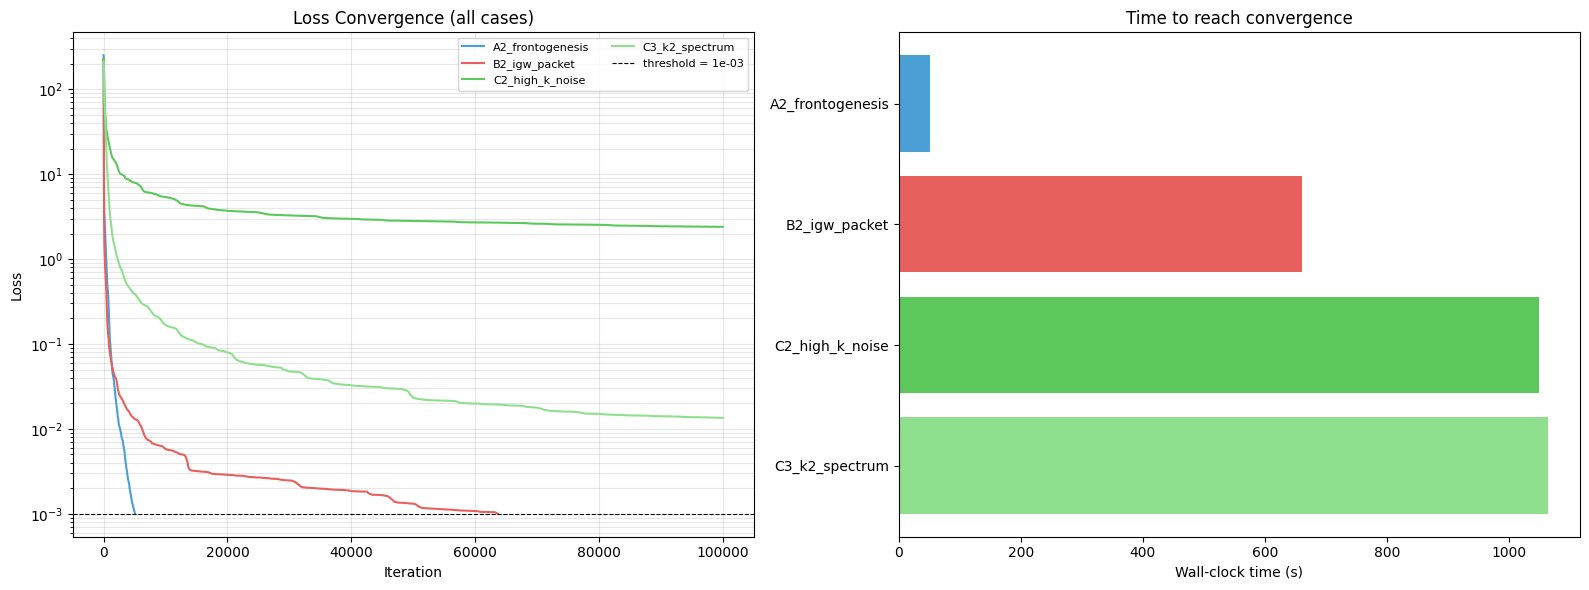

In [ ]:
# ── Summary table (with initial loss) ──
print(f"{'Case':<25} {'Init Loss':>14} {'Iters':>7} {'Time (s)':>10} {'Final Loss':>14} {'Final |grad|':>14}")
print("-" * 90)
for name, r in benchmark_results.items():
    init_loss = r['loss_history'][0] if r['loss_history'] else float('nan')
    print(f"{name:<25} {init_loss:>14.4e} {r['iters']:>7d} {r['elapsed']:>10.1f} {r['final_loss']:>14.4e} {r['final_grad']:>14.4e}")

# ── Loss convergence curves (all cases on one plot) ──
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Colour groups: A=blue shades, B=red shades, C=green shades, D=purple
group_colors = {
    'A1': '#1f77b4', 'A2': '#4a9fd4', 'A3': '#7ec8e3',
    'B1': '#d62728', 'B2': '#e8605d', 'B3': '#f09896',
    'C1': '#2ca02c', 'C2': '#5cc85c', 'C3': '#8ee08e',
    'D1': '#9467bd',
}

for name, r in benchmark_results.items():
    prefix = name[:2]
    color = group_colors.get(prefix, 'gray')
    ax1.semilogy(r['loss_history'], label=name, color=color, linewidth=1.5)

ax1.axhline(loss_threshold, color='k', linestyle='--', linewidth=0.8, label=f'threshold = {loss_threshold:.0e}')
ax1.set_xlabel('Iteration')
ax1.set_ylabel('Loss')
ax1.set_title('Loss Convergence (all cases)')
ax1.legend(fontsize=8, ncol=2)
# ax1.set_xscale('log')          # ← semi-log: linear x, log y
ax1.grid(True, which='both', alpha=0.3)   # 'both' adds minor grid ticks on log axis


# ── Bar chart: wall-clock time to convergence ──
names  = list(benchmark_results.keys())
times  = [benchmark_results[n]['elapsed'] for n in names]
colors = [group_colors.get(n[:2], 'gray') for n in names]

ax2.barh(names, times, color=colors)
ax2.set_xlabel('Wall-clock time (s)')
ax2.set_title('Time to reach convergence')
ax2.invert_yaxis()

plt.tight_layout()
plt.show()

# Result Analysis

For most of the case, the convergent is really fast. However although the final gradient is near 0, actually the lost function is not. Indicating the SQG+1 model is not capable of reconstructing a surface sea height exactly equals to the perturbed field. This is reasonable since the perturbation we added is not QG. I would compare the SSH_target with the inversed ssh. 

Available cases:
  [0] A2_frontogenesis        final_loss = 9.998e-04  |grad| = 3.178e-01
  [1] B2_igw_packet           final_loss = 1.000e-03  |grad| = 1.350e-01
  [2] C2_high_k_noise         final_loss = 2.397e+00  |grad| = 7.240e-01
  [3] C3_k2_spectrum          final_loss = 1.349e-02  |grad| = 2.288e-01

Plotting: C3_k2_spectrum

  rms(target)   = 1.184295e+00
  rms(residual) = 9.073283e-04
  rel error     = 0.0766%


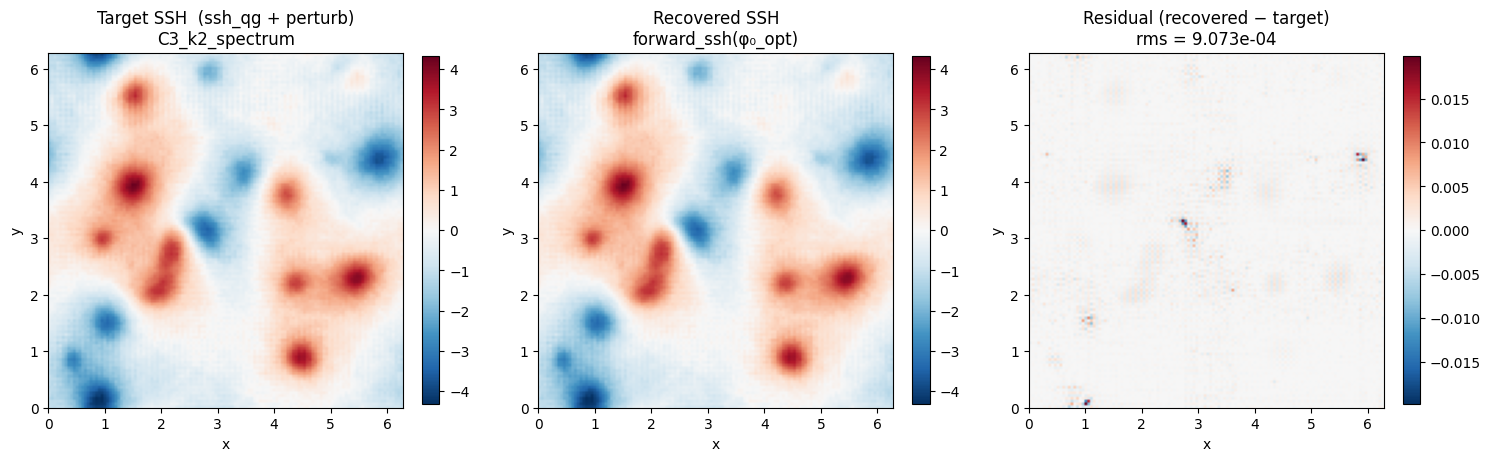

In [ ]:
# Pick which case to visualize — change this string to any key in cases
CASE_TO_PLOT = "C3_k2_spectrum"

# List available cases so you know what you can choose from
print("Available cases:")
for i, name in enumerate(cases.keys()):
    r = benchmark_results[name]
    print(f"  [{i}] {name:<22}  final_loss = {r['final_loss']:.3e}  |grad| = {r['final_grad']:.3e}")
print(f"\nPlotting: {CASE_TO_PLOT}\n")

perturb, eta_target_phys = cases[CASE_TO_PLOT]      
phi0_opt = phi0_s_optimals[CASE_TO_PLOT]            

# Forward SQG+1 SSH from the optimal streamfunction
phi0_opt_hat   = jnp.fft.fft2(phi0_opt)
eta_opt_hat    = forward_ssh(phi0_opt_hat, kx, ky,
                             mu, inv_mu, K2, inv_K2, Bu, epsilon)
eta_opt_phys   = jnp.real(jnp.fft.ifft2(eta_opt_hat))

residual       = eta_opt_phys - eta_target_phys
# residual       = eta_opt_phys - ssh_qg
rms_target     = float(jnp.sqrt(jnp.mean(eta_target_phys ** 2)))
# rms_target     = float(jnp.sqrt(jnp.mean(ssh_qg ** 2)))
rms_residual   = float(jnp.sqrt(jnp.mean(residual ** 2)))
rel_err        = rms_residual / rms_target if rms_target > 0 else float('nan')

# Comparing the original SSH


print(f"  rms(target)   = {rms_target:.6e}")
print(f"  rms(residual) = {rms_residual:.6e}")
print(f"  rel error     = {rel_err:.4%}")

# Code for plot
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), constrained_layout=True)

# Shared colour scale for target / recovered so they're visually comparable
vmax = float(jnp.max(jnp.abs(eta_target_phys)))
im0 = axes[0].imshow(eta_target_phys, origin='lower', cmap='RdBu_r',
                     vmin=-vmax, vmax=vmax,
                     extent=[0, float(Lx), 0, float(Ly)])
axes[0].set_title(f"Target SSH  (ssh_qg + perturb)\n{CASE_TO_PLOT}")
plt.colorbar(im0, ax=axes[0], fraction=0.046)

im1 = axes[1].imshow(eta_opt_phys, origin='lower', cmap='RdBu_r',
                     vmin=-vmax, vmax=vmax,
                     extent=[0, float(Lx), 0, float(Ly)])
axes[1].set_title("Recovered SSH\nforward_ssh(φ₀_opt)")
plt.colorbar(im1, ax=axes[1], fraction=0.046)

# im3 = axes[3].imshow(ssh_qg, origin='lower', cmap = 'RdBu_r',
#                     vmin = -vmax, vmax = vmax,
#                     extent = [0, float(Lx), 0, float(Ly)])
# axes[3].set_title("Initial Geostrophic SSH field")
# plt.colorbar(im1, ax=axes[2], fraction=0.046)

# Residual on its own scale
rvmax = float(jnp.max(jnp.abs(residual)))
im2 = axes[2].imshow(residual, origin='lower', cmap='RdBu_r',
                     vmin=-rvmax, vmax=rvmax,
                     extent=[0, float(Lx), 0, float(Ly)])
axes[2].set_title(f"Residual (recovered − target)\nrms = {rms_residual:.3e}")
plt.colorbar(im2, ax=axes[2], fraction=0.046)

for ax in axes:
    ax.set_xlabel("x"); ax.set_ylabel("y")

plt.show()


# Compare the Result

What is actually interested would be the QG field, $u_qg$. The perturbation added would be noise that influence the inversion but not what we are interested in. 

Below I compare the surface velocity field from the optimal variable $\Phi^0$ and input into the SQG+1 model and the velocity field from the original QG simulation. 

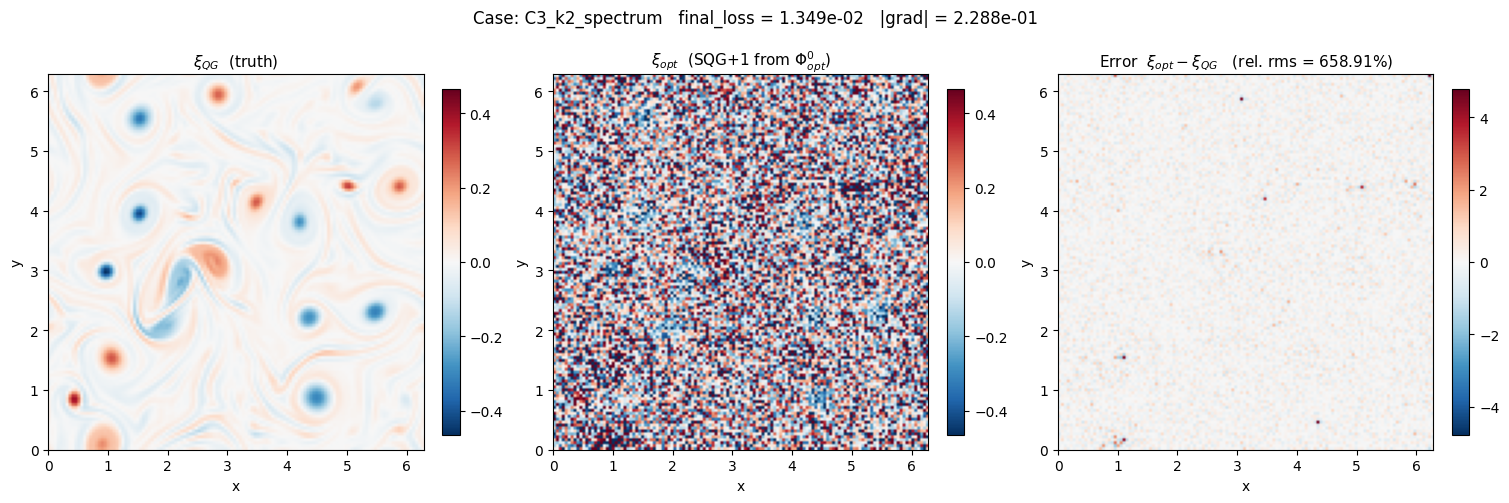

In [168]:
# ── Case selector ──────────────────────────────────────────────────────────────
CASE_TO_PLOT = "C3_k2_spectrum"   # change to any key in cases

# ── QG truth vorticity (computed once, same for all cases) ────────────────────
zeta_qg = jnp.real(jnp.fft.ifft2(-K2 * phi0_s_hat))

# ── Per-case recovered vorticity from SQG+1 velocity ─────────────────────────
def compute_zeta_from_phi(phi_hat):
    u, v = calculate_surface_u(phi_hat, mu, inv_mu, kx, ky, K2, inv_K2, epsilon, Bu)
    zeta = jnp.real(jnp.fft.ifft2(
        1j * kx * jnp.fft.fft2(v) - 1j * ky * jnp.fft.fft2(u)
    ))
    return u, v, zeta

# Print summary table for all cases
rms_zeta_qg = float(jnp.sqrt(jnp.mean(zeta_qg**2)))
for name in cases.keys():
    phi_hat = jnp.fft.fft2(phi0_s_optimals[name])
    _, _, zeta_opt = compute_zeta_from_phi(phi_hat)
    rel_err = float(jnp.sqrt(jnp.mean((zeta_opt - zeta_qg)**2))) / rms_zeta_qg

# ── Build fields for the chosen case ──────────────────────────────────────────
phi0_opt_hat = jnp.fft.fft2(phi0_s_optimals[CASE_TO_PLOT])
u_opt, v_opt, zeta_opt = compute_zeta_from_phi(phi0_opt_hat)

zeta_err = zeta_opt - zeta_qg
rel_zeta_err = float(jnp.sqrt(jnp.mean(zeta_err**2))) / rms_zeta_qg

# ── Plot ───────────────────────────────────────────────────────────────────────
extent = [0, float(Lx), 0, float(Ly)]
vmax_z = float(jnp.max(jnp.abs(zeta_qg)))

fig, axes = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)

titles = [
    r"$\xi_{QG}$  (truth)",
    r"$\xi_{opt}$  (SQG+1 from $\Phi^0_{opt}$)",
    rf"Error  $\xi_{{opt}} - \xi_{{QG}}$   (rel. rms = {rel_zeta_err:.2%})",
]
fields = [zeta_qg, zeta_opt, zeta_err]

for ax, field, title in zip(axes, fields, titles):
    vmax = vmax_z if "Error" not in title else float(jnp.max(jnp.abs(zeta_err)))
    im = ax.imshow(field, origin='lower', cmap='RdBu_r',
                   vmin=-vmax, vmax=vmax, extent=extent)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("x"); ax.set_ylabel("y")
    plt.colorbar(im, ax=ax, fraction=0.046)

fig.suptitle(
    f"Case: {CASE_TO_PLOT}   "
    f"final_loss = {benchmark_results[CASE_TO_PLOT]['final_loss']:.3e}   "
    f"|grad| = {benchmark_results[CASE_TO_PLOT]['final_grad']:.3e}",
    fontsize=12
)
plt.show()


# Evaluation Metric?

I propose we can may plot the spectral error decomposition 

$$ E(k) = \frac{|\hat{\xi}_{opt} - \hat{\xi}_{qg}|^2}{|\hat{\xi_{qg}}|^2} $$

This seperates the low-k error and High-k error. 

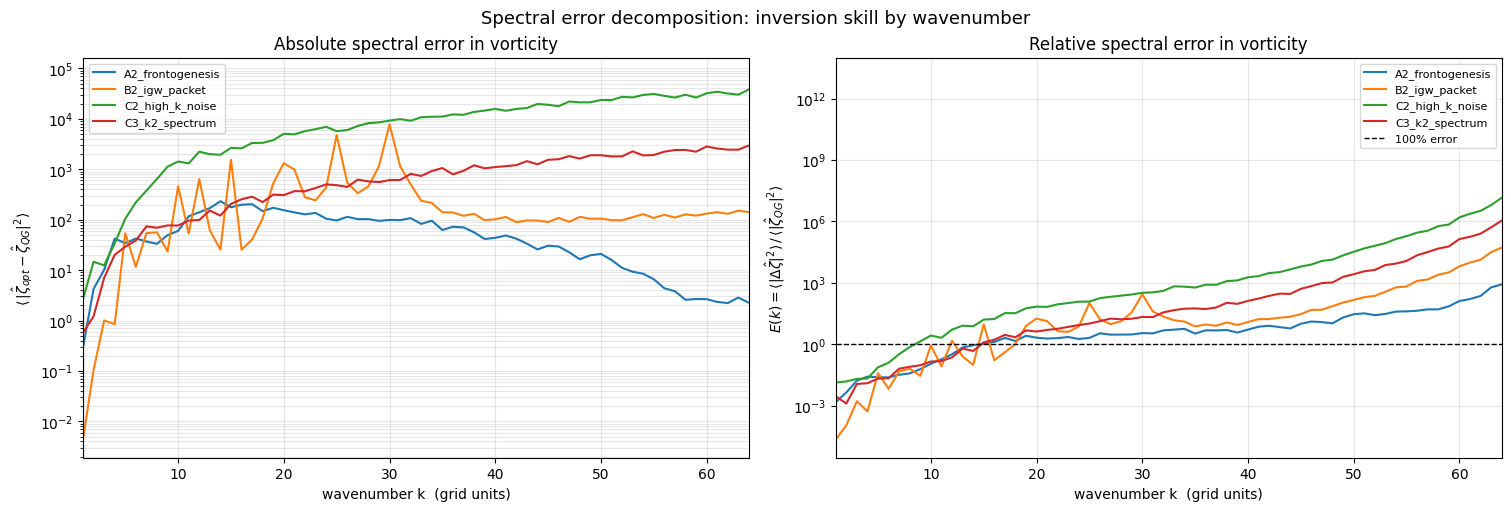

In [166]:
import matplotlib.pyplot as plt
import numpy as np

def azimuthal_spectrum(field_2d, K, dk):
    """
    Azimuthal average of a 2D spectral field, binned by integer wavenumber.
    Returns k_integers (1D) and the binned spectrum.
    """
    K_np     = np.array(K)
    field_np = np.array(np.real(field_2d))          # power is real
    k_int    = np.round(K_np / dk).astype(int)       # integer wavenumber index
    k_max    = k_int.max()

    spectrum = np.zeros(k_max + 1)
    counts   = np.zeros(k_max + 1)
    np.add.at(spectrum, k_int.ravel(), field_np.ravel())
    np.add.at(counts,   k_int.ravel(), 1)

    counts   = np.where(counts > 0, counts, np.nan)
    spectrum = spectrum / counts                      # mean power per annulus
    k_axis   = np.arange(k_max + 1)
    return k_axis, spectrum

def spectral_error(phi0_opt_hat, phi0_s_hat, mu, inv_mu, kx, ky,
                   K, K2, inv_K2, epsilon, Bu, dk):
    """
    Azimuthally-averaged relative spectral error in vorticity:

        E(k) = <|ζ̂_opt(k) - ζ̂_qg(k)|²> / <|ζ̂_qg(k)|²>

    ζ_qg  : pure QG truth  =  ifft2(-K² φ̂₀)
    ζ_opt : SQG+1 recovered via calculate_surface_u(φ̂₀_opt)
    """
    # QG truth vorticity (spectral)
    zeta_qg_hat = -K2 * phi0_s_hat

    # SQG+1 recovered vorticity (spectral)
    u_opt, v_opt = calculate_surface_u(phi0_opt_hat, mu, inv_mu,
                                       kx, ky, K2, inv_K2, epsilon, Bu)
    zeta_opt_hat = 1j * kx * jnp.fft.fft2(v_opt) - 1j * ky * jnp.fft.fft2(u_opt)

    err_power    = jnp.abs(zeta_opt_hat - zeta_qg_hat) ** 2
    signal_power = jnp.abs(zeta_qg_hat) ** 2

    k_axis, err_spec    = azimuthal_spectrum(err_power,    K, dk)
    _,      signal_spec = azimuthal_spectrum(signal_power, K, dk)

    # Relative error; NaN where signal is negligible
    with np.errstate(invalid='ignore', divide='ignore'):
        rel_spec = np.where(signal_spec > 1e-30, err_spec / signal_spec, np.nan)

    return k_axis, err_spec, signal_spec, rel_spec

# ── dk from the simulation grid ───────────────────────────────────────────────
dk = float(2.0 * jnp.pi / Nx)    # matches how kx/ky are built in spectral_main.py

# ── QG signal spectrum (reference, same for every case) ───────────────────────
zeta_qg_hat  = -K2 * phi0_s_hat
k_axis, signal_spec = azimuthal_spectrum(jnp.abs(zeta_qg_hat)**2, K, dk)

# ── Plot ───────────────────────────────────────────────────────────────────────
CASES_TO_PLOT = list(cases.keys())

fig, axes = plt.subplots(1, 2, figsize=(15, 5), constrained_layout=True)
ax_abs, ax_rel = axes

for name in CASES_TO_PLOT:
    phi0_opt_hat = jnp.fft.fft2(phi0_s_optimals[name])
    k_axis, err_spec, _, rel_spec = spectral_error(
        phi0_opt_hat, phi0_s_hat, mu, inv_mu,
        kx, ky, K, K2, inv_K2, epsilon, Bu, dk
    )
    ax_abs.semilogy(k_axis, err_spec,  label=name)
    ax_rel.semilogy(k_axis, rel_spec,  label=name)

for ax in axes:
    ax.set_xlabel("wavenumber k  (grid units)")
    ax.set_xlim(1, Nx // 2)
    ax.grid(True, which='both', alpha=0.3)
    ax.legend(fontsize=8)

ax_abs.set_ylabel(r"$\langle\,|\hat{\zeta}_{opt} - \hat{\zeta}_{QG}|^2\rangle$")
ax_abs.set_title("Absolute spectral error in vorticity")

ax_rel.set_ylabel(r"$E(k) = \langle|\Delta\hat{\zeta}|^2\rangle\,/\,\langle|\hat{\zeta}_{QG}|^2\rangle$")
ax_rel.set_title("Relative spectral error in vorticity")
ax_rel.axhline(1.0, color='k', ls='--', lw=1, label='100% error')
ax_rel.legend(fontsize=8)

fig.suptitle("Spectral error decomposition: inversion skill by wavenumber", fontsize=13)
plt.show()


In [137]:
import dill

to_save = {
    'benchmark_results': benchmark_results,
    'phi0_s_optimals':   phi0_s_optimals,
    'cases':             cases,
    'phi0_s':            phi0_s,
    'phi0_s_hat':        phi0_s_hat,
    'kx': kx, 'ky': ky, 'K': K, 'K2': K2, 'inv_K2': inv_K2,
    'mu': mu, 'inv_mu': inv_mu,
    'Ro': Ro, 'epsilon': epsilon, 'Bu': Bu,
    'Nx': Nx, 'Ny': Ny, 'Lx': Lx, 'Ly': Ly,
    'X': X, 'Y': Y,
}
with open('workspace_0412_run3.pkl', 'wb') as f:
    dill.dump(to_save, f)
